## Exploration & Plotting script

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# paths
DATA = "../data/preprocessed_db.csv"

PLOTS_DIR = "../results/exploration"

In [4]:
## load merged df
df = pd.read_csv(DATA)
df.head()

,record_id,sexo,fecha_ingreso,fecha_alta,IRAs_nosocomial,mortalidad,mortalidad_30_dias,uci_por_el_episodio,duracion_UCI,mujer_gestante,...,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit,antimicrobiano_list,cmi_list,interpretacion_list,antimicrobiano_family_list,ingreso_prev_indicator
0,1,0,2021-08-24,2021-09-09,1,1,1,1,14,0,...,0,1,0,0,0,"['Cefazolina', 'Trimetoprim', 'Ertapenem', 'Ce...","['>16 mg/L', '>4 mg/L', '>1 mg/L', '>8 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'I', ...","['Cefalosporin', 'TMP_SMX', 'Carbapenem', 'Cef...",0
1,2,1,2023-06-18,2023-07-13,1,0,0,1,3,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Cefuroxima', ...","['>4/76 mg/L', '<=8 mg/L', '0.5 mg/L', '<=0.5 ...","['R', 'I', 'I', 'S', 'S', 'S', 'S', 'S', 'S', ...","['TMP_SMX', 'Cefalosporin', 'Quinolone', 'Quin...",0
2,3,0,2022-02-11,2022-04-06,1,0,0,1,24,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Ampicilina', ...","['>4/76 mg/L', '>8 mg/L', '>4 mg/L', '>1 mg/L'...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Penicillin', 'Aminoglycoside', 'Q...",1
3,4,0,2021-05-15,2021-07-28,1,0,0,1,42,0,...,0,1,0,0,0,"['Trimetoprim', 'Levofloxacino', 'Ertapenem', ...","['>4 mg/L', '>1 mg/L', '>1 mg/L', '>16 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Quinolone', 'Carbapenem', 'Cefalo...",1
4,5,1,2021-07-04,2022-01-04,1,0,0,1,78,0,...,0,0,0,0,0,"['Aztreonam', 'Ciprofloxacino', 'Ceftazidima',...","['<=1 mg/L', '>1 mg/L', '<=1 mg/L', '>8 mg/L',...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['Monobactam', 'Quinolone', 'Cefalosporin', 'C...",0


/tmp/ipykernel_8604/96692869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts1.index, y=counts1.values, palette='Set2', ax=ax[0])
/tmp/ipykernel_8604/96692869.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts2.index, y=counts2.values, palette='Set2', ax=ax[1])


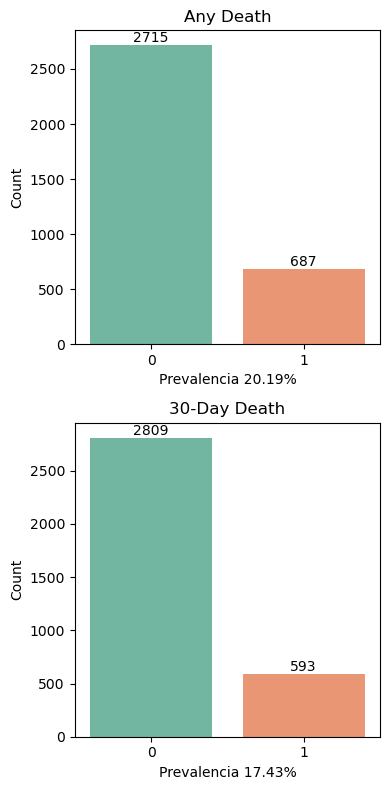

In [5]:
# Mortality prevalence
fig, ax = plt.subplots(2,1, figsize=(4, 8))

# Stage 1: any death
counts1 = df['mortalidad'].value_counts().sort_index()
sns.barplot(x=counts1.index, y=counts1.values, palette='Set2', ax=ax[0])
prevalence_any = df['mortalidad'].sum() / df.shape[0]
ax[0].set_title('Any Death')
ax[0].set_xlabel(f"Prevalencia {prevalence_any:.2%}")
ax[0].set_ylabel('Count')
for i, v in enumerate(counts1.values):
    ax[0].text(i, v + max(counts1.values)*0.01, str(v), ha='center')

# Stage 2: 30-day death
counts2 = df['mortalidad_30_dias'].value_counts().sort_index()
sns.barplot(x=counts2.index, y=counts2.values, palette='Set2', ax=ax[1])
prevalence_30d = df['mortalidad_30_dias'].sum() / df.shape[0]
ax[1].set_title('30-Day Death')
ax[1].set_xlabel(f"Prevalencia {prevalence_30d:.2%}")
ax[1].set_ylabel('Count')
for i, v in enumerate(counts2.values):
    ax[1].text(i, v + max(counts2.values)*0.01, str(v), ha='center')

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/mortality_overview.png")
plt.show()
